## Image-to-Text Recognition module script creation

#### Input
@[Bot-Name] /translate [attachment]

#### Output


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\alexj\Documents\VSCode Repositories\Discord-TL_Bot\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected [en] text: Jon Yesterday at 5:22PM with confidence: 75.29% 
Detected [tl] text: Is with confidence: 99.15% 
Detected [en] text:  @coach hug赢家的视角 the solo q streamer promised to save the discord with confidence: 50.12% 
Detected [en] text:  coach hug 赢家的视角  e ONK  Yesterdayat 523PM with confidence: 15.5% 
Detected [tl] text: no with confidence: 99.37% 
Detected [en] text:  REFORMED MENO JUNGLE Yesterday at5:24PM with confidence: 54.26% 
Detected [tr] text: yes with confidence: 99.19% 


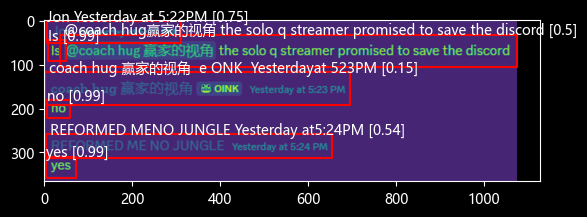

In [1]:
# EasyOCR script
from langdetect import detect
import cv2
import easyocr
import matplotlib.pyplot as plt

# Run only once to load the model into memory
reader = easyocr.Reader(['en','ch_sim']) #, 'ja', 'ko'])

# read the image
image_filename = 'test_image_4.png'
img = cv2.imread(image_filename)

# Preprocess for better accuracy
scale = 2
img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# run OCR
results = reader.readtext(img, width_ths=1e4, add_margin=0.1, low_text=0.1, text_threshold=0.8, paragraph=False)
for res in results:
    # print(res)
    try:
        lang = detect(res[1])
    except:
        lang = "N/A"
    print(f"Detected [{lang}] text: {res[1]} with confidence: {round(res[2]*100, 2)}% ")

# show the image and plot the results
plt.rcParams['font.family'] = ['sans-serif'] # set for CJK characters
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Meiryo', 'SimHei', 'Arial'] # set to include CJK characters
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'text.color': "white",
    'axes.labelcolor': "white",
    'xtick.color': "white",
    'ytick.color': "white"
})
plt.style.use('dark_background')

plt.imshow(img)
for res in results:
    # bbox coordinates of the detected text
    xy = res[0]
    xy1, xy2, xy3, xy4 = xy[0], xy[1], xy[2], xy[3]
    # text results and confidence of detection
    det, conf = res[1], res[2]
    # show time :)
    plt.plot([xy1[0], xy2[0], xy3[0], xy4[0], xy1[0]], [xy1[1], xy2[1], xy3[1], xy4[1], xy1[1]], 'r-')
    plt.text(xy1[0], xy1[1], f'{det} [{round(conf, 2)}]')

In [17]:
# Tesseract OCR & OpenCV
import pytesseract
import cv2
from PIL import Image
from langdetect import detect

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# Tesseract Flags
# https://muthu.co/all-tesseract-ocr-options/
custom_config = r'-l eng+jpn+chi_sim+chi_tra+kor --oem 3 --psm 3'

image_filename = 'test_image_4.png'

pil_text = pytesseract.image_to_string(Image.open(image_filename), config=custom_config)
print(pil_text)

file_image = cv2.imread(image_filename)
cv_text = pytesseract.image_to_string(file_image, config=custom_config)
print(cv_text)

text = pytesseract.image_to_data(file_image, config=custom_config, output_type=pytesseract.Output.DATAFRAME)
print(text)
text = text[text['conf'] != -1]
lines = text.groupby('block_num')['text'].apply(list)
print(lines)
conf = text.groupby('block_num')['conf'].apply(list)
print(conf)

Jon Yesterday at 5:22 PM
ls @coach hug 贏家 的 視角 the solo q streamer promised to save the discord

coach hug 항주 디케 (BOINK) Yesterday at 5:23 PM
no

REFORMED ME NO JUNGLE ‘Yesterday at 5:24PM
yes

Jon Yesterday at 5:22 PM
ls @coach hug 贏家 的 視角 the solo q streamer promised to save the discord

coach hug 280/15 (GOINK) Yesterday at 5:23 PM
no

REFORMED ME NO JUNGLE Yesterday at 5:24PM
yes

    level  page_num  block_num  par_num  line_num  word_num  left  top  width  \
0       1         1          0        0         0         0     0    0    537   
1       2         1          1        0         0         0     9    7    519   
2       3         1          1        1         0         0     9    7    519   
3       4         1          1        1         1         0     9    7    140   
4       5         1          1        1         1         1     9    7     23   
5       5         1          1        1         1         2    42    9     50   
6       5         1          1        1      

In [ ]:
# # Pyocr
# import sys

# import PIL.Image
# import pyocr
# import pyocr.builders

# tools = pyocr.get_available_tools()
# if len(tools) == 0:
#     print("No OCR tool found")
#     sys.exit(1)
# ocr_tool = tools[0]

# image_filename = 'test_image.png'

# image = PIL.Image.open(image_filename)

# text = ocr_tool.image_to_string(image, builder=pyocr.builders.TextBuilder())

# print(text)

In [ ]:
# import requests
# from PIL import Image

# from transformers import TrOCRProcessor, VisionEncoderDecoderModel


# processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
# model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten", device_map="auto")

# # load image from the IAM dataset
# # url = "https://fki.tic.heia-fr.ch/static/img/a01-122-02.jpg"

# image_filename = 'test_image_4.png'

# image = Image.open(image_filename).convert("RGB")

# pixel_values = processor(image, return_tensors="pt").to(model.device).pixel_values
# generated_ids = model.generate(pixel_values)

# generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
# print(generated_text)